In [11]:
import pandas as pd  
  
# Load the dataset  
df = pd.read_csv('./data/resale_transactions.csv')

In [12]:
df.head()

,id,month,flat_type,block,street_name,storey_range,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,town_id,flatm_id,town_name,flatm_name
0,1,2018-05,5 ROOM,118,PASIR RIS ST 11,07 TO 09,123.0,1989,70 years 03 months,488000.0,17,5,PASIR RIS,Improved
1,2,2016-10,4 ROOM,101,RIVERVALE WALK,01 TO 03,100.0,1999,81,345000.0,21,8,SENGKANG,Model A
2,3,2018-10,5 ROOM,688A,CHOA CHU KANG DR,19 TO 21,110.0,2002,82 years 06 months,370000.0,9,5,CHOA CHU KANG,Improved
3,4,2015-12,4 ROOM,130,LOR AH SOO,13 TO 15,103.0,1984,67,432000.0,12,8,HOUGANG,Model A
4,5,2017-09,5 ROOM,533,SERANGOON NTH AVE 4,07 TO 09,122.0,1992,74 years 02 months,500000.0,22,5,SERANGOON,Improved


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88688 entries, 0 to 88687
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   88688 non-null  int64  
 1   month                88688 non-null  object 
 2   flat_type            88688 non-null  object 
 3   block                88688 non-null  object 
 4   street_name          88688 non-null  object 
 5   storey_range         88688 non-null  object 
 6   floor_area_sqm       88688 non-null  float64
 7   lease_commence_date  88688 non-null  int64  
 8   remaining_lease      88688 non-null  object 
 9   resale_price         88688 non-null  float64
 10  town_id              88688 non-null  int64  
 11  flatm_id             88688 non-null  int64  
 12  town_name            87905 non-null  object 
 13  flatm_name           88174 non-null  object 
dtypes: float64(2), int64(4), object(8)
memory usage: 9.5+ MB


In [14]:
df.isnull().sum()

id                       0
month                    0
flat_type                0
block                    0
street_name              0
storey_range             0
floor_area_sqm           0
lease_commence_date      0
remaining_lease          0
resale_price             0
town_id                  0
flatm_id                 0
town_name              783
flatm_name             514
dtype: int64

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,88688.0,42233.303739,24376.312037,1.0,21136.75,42228.5,63339.25,84465.0
floor_area_sqm,88688.0,97.520444,24.197379,31.0,76.00,96.0,112.00,280.0
lease_commence_date,88688.0,1570.225352,1226.315949,-2016.0,1980.00,1988.0,2000.00,2016.0
resale_price,88688.0,438679.303299,146670.254508,160000.0,335000.00,408000.0,505000.00,1200000.0
town_id,88688.0,14.631337,8.032285,1.0,8.00,15.0,22.00,26.0
flatm_id,88688.0,8.889185,3.906898,1.0,5.00,8.0,12.00,21.0


In [16]:
df.duplicated().sum()

4223

In [17]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

,id,month,flat_type,block,street_name,storey_range,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,town_id,flatm_id,town_name,flatm_name
103,104,2016-09,3 ROOM,201E,TAMPINES ST 23,04 TO 06,68.0,-1987,70,305000.0,23,12,TAMPINES,New Generation
88570,104,2016-09,3 ROOM,201E,TAMPINES ST 23,04 TO 06,68.0,-1987,70,305000.0,23,12,TAMPINES,New Generation
106,107,2015-08,4 ROOM,146,SERANGOON NTH AVE 1,13 TO 15,83.0,-1987,70,355000.0,22,17,SERANGOON,Simplified
88156,107,2015-08,4 ROOM,146,SERANGOON NTH AVE 1,13 TO 15,83.0,-1987,70,355000.0,22,17,SERANGOON,Simplified
114,115,2017-03,4 ROOM,274D,PUNGGOL PL,16 TO 18,93.0,2013,95 years 04 months,560000.0,18,13,PUNGGOL,Premium Apartment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87372,84427,2019-01,5 ROOM,348D,YISHUN AVE 11,13 TO 15,112.0,2013,93 years 09 months,758000.0,26,4,YISHUN,DBSS
84428,84429,2018-10,4 ROOM,838,HOUGANG CTRL,04 TO 06,100.0,-1997,77 years 05 months,530000.0,12,8,HOUGANG,Model A
85835,84429,2018-10,4 ROOM,838,HOUGANG CTRL,04 TO 06,100.0,-1997,77 years 05 months,530000.0,12,8,HOUGANG,Model A
84461,84462,2015-06,5 ROOM,596A,ANG MO KIO ST 52,07 TO 09,110.0,2002,86,760000.0,1,5,ANG MO KIO,Improved


In [18]:
df.drop_duplicates(inplace=True)

Creating Bar Chart
---------

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Bar chart for flat type with annotations
plt.figure(figsize=(10, 6))
count_plot = sns.countplot(x='flat_type', data=df)
plt.title('Count of Different Flat Types')
plt.xlabel('Flat Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Annotate the bars with the frequency count
for p in count_plot.patches:
    count_plot.annotate(format(p.get_height(), '.0f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points')

plt.show()

<Figure size 1000x600 with 1 Axes>

In [21]:
# Replace 'FOUR ROOM' with '4 ROOM' in the 'flat_type' column
df['flat_type'] = df['flat_type'].replace('FOUR ROOM', '4 ROOM')
  
# Verify the changes
print(df['flat_type'].value_counts())

flat_type
4 ROOM              34828
3 ROOM              21490
5 ROOM              20449
EXECUTIVE            6685
2 ROOM                944
1 ROOM                 38
MULTI-GENERATION       31
Name: count, dtype: int64


Creating Histogram
------------------

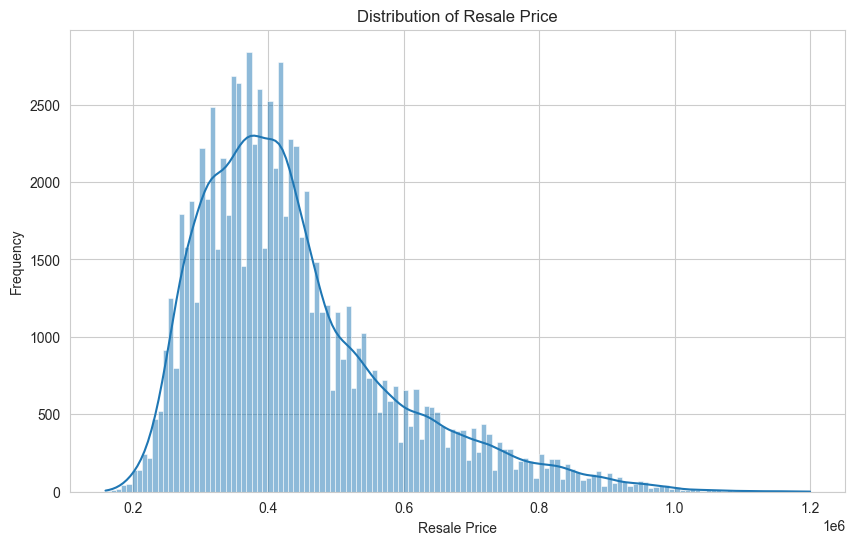

In [22]:
# Set the aesthetic style of the plots  
sns.set_style("whitegrid")  
  
# Histogram for resale price  
plt.figure(figsize=(10, 6))  
sns.histplot(df['resale_price'], kde=True)  
plt.title('Distribution of Resale Price')  
plt.xlabel('Resale Price')  
plt.ylabel('Frequency')  
plt.show()

Creating Line Chart
-------------------

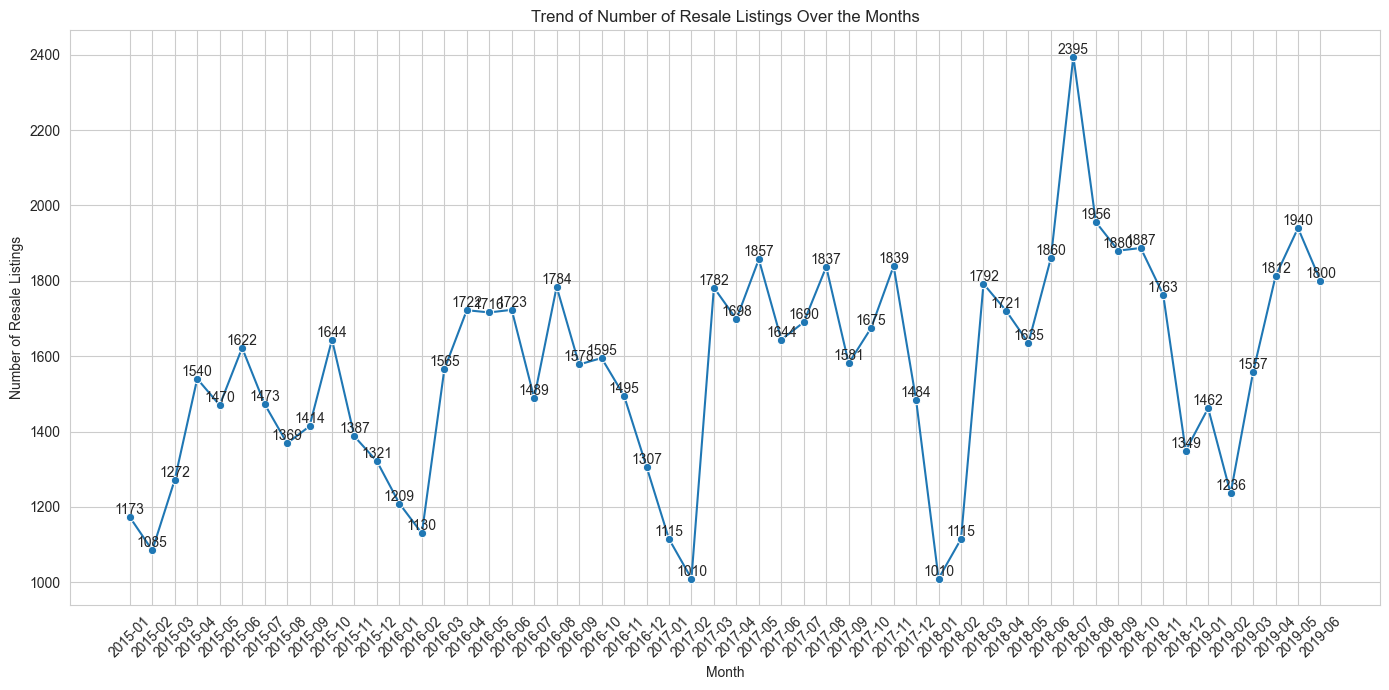

In [23]:
# Set Aesthetic Style
sns.set_style("whitegrid")

# Count the Number of Listings by Month
month_counts = df['month'].value_counts().sort_index()

# Create the Line Chart
plt.figure(figsize=(14, 7))
line_plot = sns.lineplot(x=month_counts.index, y=month_counts.values, marker='o')

# Annotate the Data Points
for x, y in zip(month_counts.index, month_counts.values):
    plt.text(x, y, f'{y}', ha='center', va='bottom')

# Label the Chart
plt.title('Trend of Number of Resale Listings Over the Months')
plt.xlabel('Month')
plt.ylabel('Number of Resale Listings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Creating Box Plot
-----------------

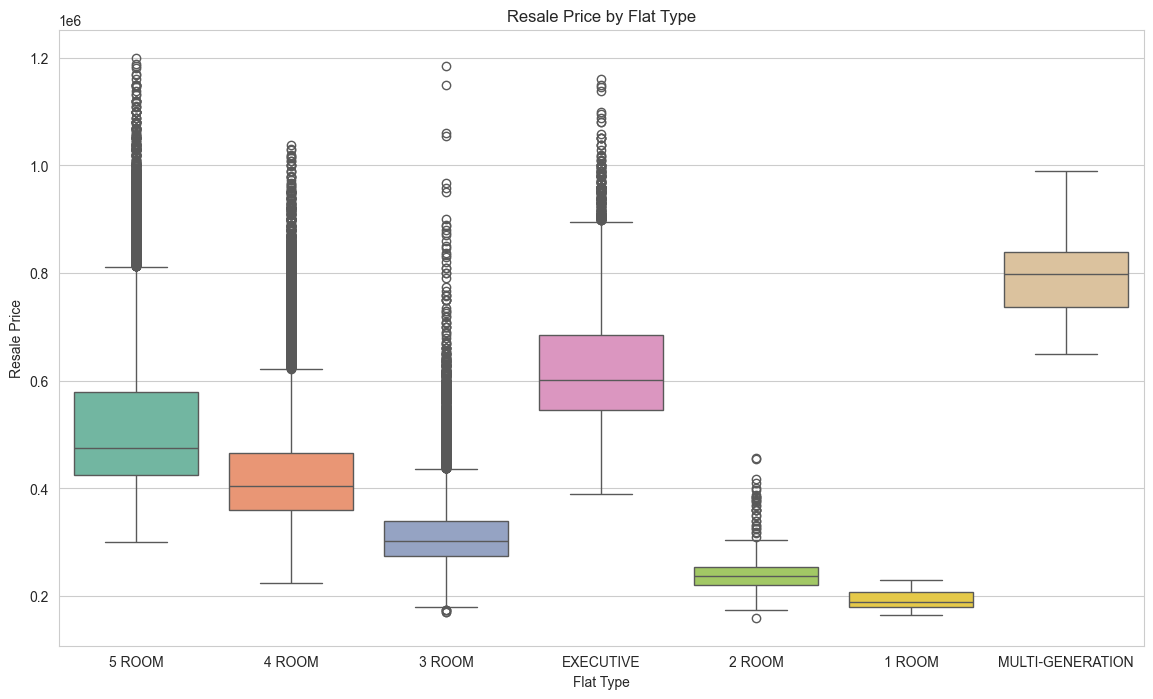

In [24]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Box plot for flat_type vs resale_price  
plt.figure(figsize=(14, 8))  
sns.boxplot(x='flat_type', y='resale_price', data=df, hue='flat_type', palette='Set2')  
plt.title('Resale Price by Flat Type')
plt.xlabel('Flat Type')
plt.ylabel('Resale Price')
plt.xticks(rotation=0)
plt.show()

Creating Subplot Bar Charts
---------------------------

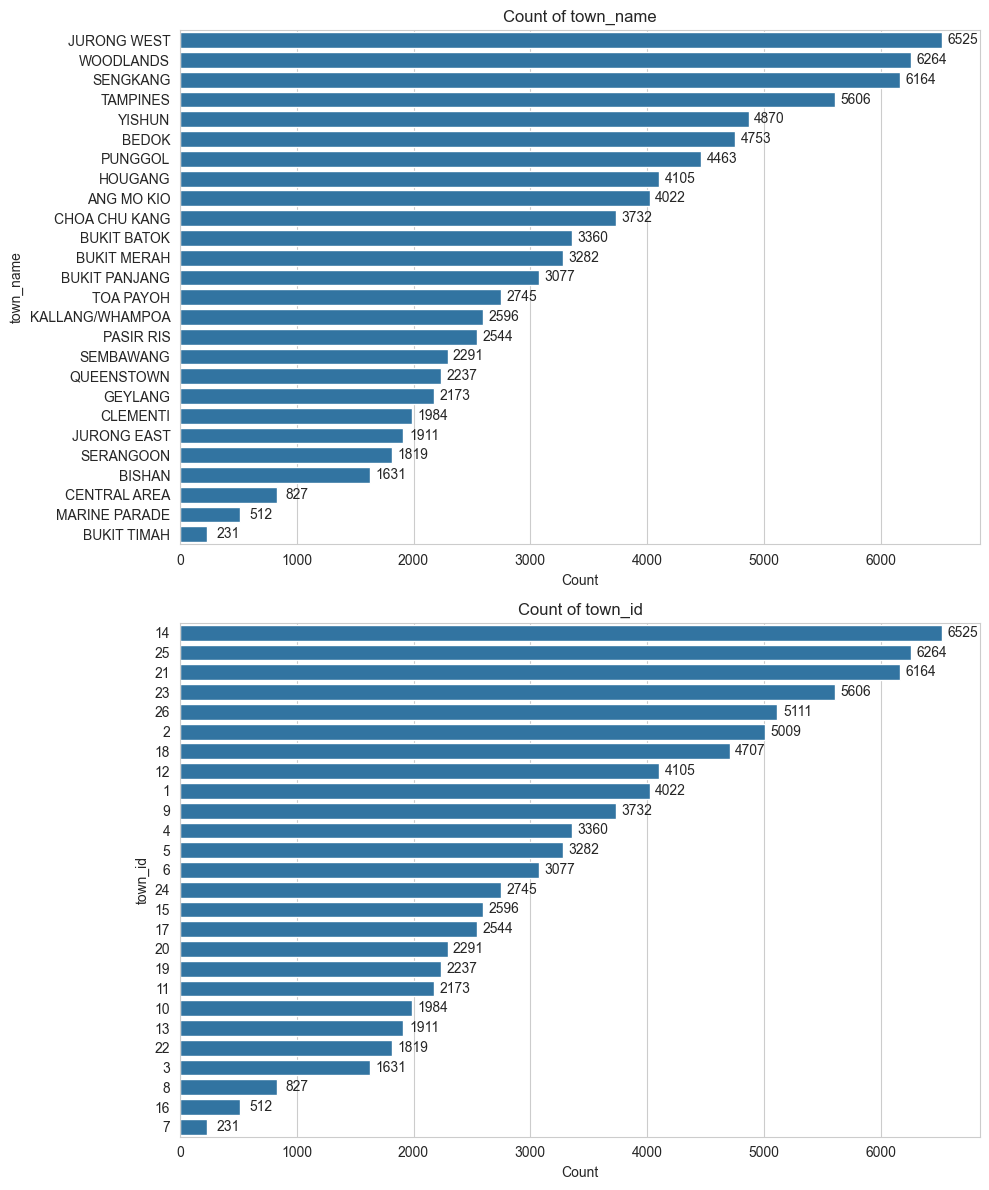

In [25]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure with 2 subplots (one above the other)
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# Sort the town_name by count
sorted_town_name = df['town_name'].value_counts().index

# Count plot for town_name with annotations
count_plot_1 = sns.countplot(y='town_name', data=df, order=sorted_town_name, ax=axes[0])
axes[0].set_title('Count of town_name')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('town_name')

# Annotate the bars with the frequency count
for p in count_plot_1.patches:
    count_plot_1.annotate(format(p.get_width(), '.0f'),
                          (p.get_width(), p.get_y() + p.get_height() / 2),
                          ha='center', va='center',
                          xytext=(15, 0),
                          textcoords='offset points')

# Sort the town_id by count
sorted_town_id = df['town_id'].value_counts().index

# Count plot for town_id with annotations
count_plot_2 = sns.countplot(y='town_id', data=df, order=sorted_town_id, ax=axes[1])
axes[1].set_title('Count of town_id')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('town_id')

# Annotate the bars with the frequency count
for p in count_plot_2.patches:
    count_plot_2.annotate(format(p.get_width(), '.0f'),
                          (p.get_width(), p.get_y() + p.get_height() / 2),
                          ha='center', va='center',
                          xytext=(15, 0),
                          textcoords='offset points')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the combined plot
plt.show()

Creating Scatter Plot
---------------------

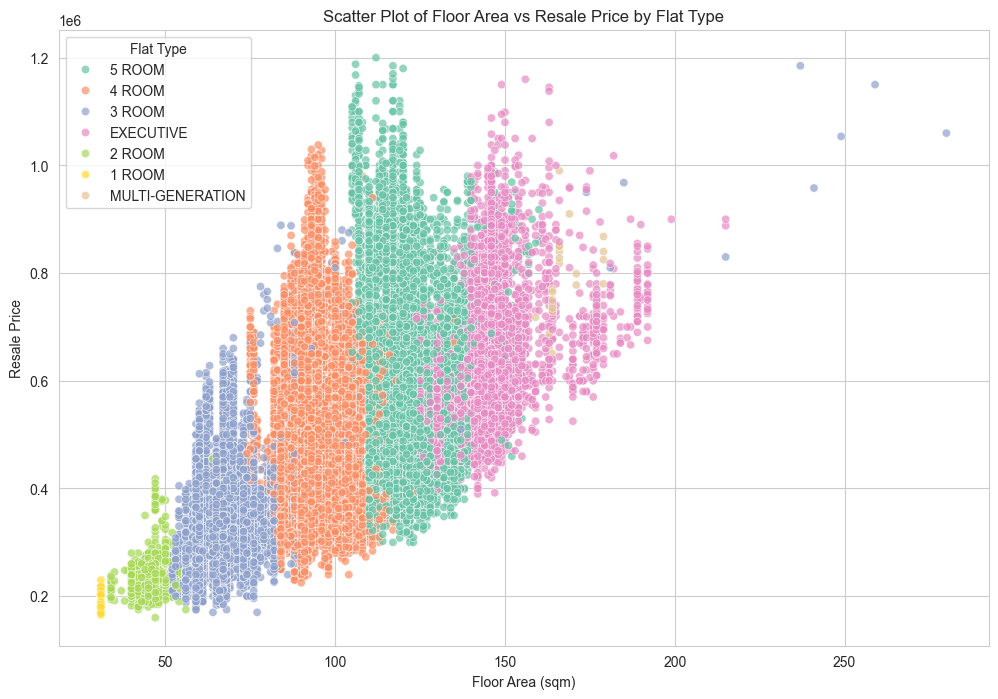

In [26]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Scatter plot for floor area vs resale price with color encoding for flat type
plt.figure(figsize=(12, 8))
sns.scatterplot(x='floor_area_sqm', y='resale_price', hue='flat_type', data=df, palette='Set2', alpha=0.7)
plt.title('Scatter Plot of Floor Area vs Resale Price by Flat Type')
plt.xlabel('Floor Area (sqm)')
plt.ylabel('Resale Price')
plt.legend(title='Flat Type')
plt.show()

In [27]:
# Filter the data for outliers
outliers = df[(df['flat_type'] == '3 ROOM') & 
                        (df['floor_area_sqm'] > 150) & 
                        (df['resale_price'] > 800000)]

# Display the outliers
outliers

,id,month,flat_type,block,street_name,storey_range,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,town_id,flatm_id,town_name,flatm_name
856,857,2018-09,3 ROOM,41,JLN BAHAGIA,01 TO 03,237.0,1972,52 years 10 months,1185000.0,15,19,KALLANG/WHAMPOA,Terrace
7472,7473,2018-06,3 ROOM,58,JLN MA'MOR,01 TO 03,174.0,1972,53 years 02 months,950000.0,15,19,KALLANG/WHAMPOA,Terrace
31858,31859,2015-03,3 ROOM,53,JLN MA'MOR,01 TO 03,280.0,1972,56,1060000.0,15,19,KALLANG/WHAMPOA,Terrace
47739,47740,2017-12,3 ROOM,65,JLN MA'MOR,01 TO 03,249.0,1972,53 years 07 months,1053888.0,15,19,KALLANG/WHAMPOA,Terrace
51992,51993,2018-05,3 ROOM,44,JLN BAHAGIA,01 TO 03,185.0,1972,53 years 02 months,968000.0,15,19,KALLANG/WHAMPOA,Terrace
54578,54579,2016-12,3 ROOM,57,JLN MA'MOR,01 TO 03,259.0,1972,54,1150000.0,15,19,KALLANG/WHAMPOA,Terrace
61997,61998,2017-05,3 ROOM,59,JLN MA'MOR,01 TO 03,181.0,1972,54 years 02 months,810000.0,15,19,KALLANG/WHAMPOA,Terrace
66428,66429,2017-06,3 ROOM,38,JLN BAHAGIA,01 TO 03,215.0,1972,54 years 01 month,830000.0,15,19,KALLANG/WHAMPOA,Terrace
78787,78788,2015-06,3 ROOM,60,JLN BAHAGIA,01 TO 03,241.0,1972,56,958000.0,15,19,KALLANG/WHAMPOA,Terrace


In [28]:
# Further filter the data for 3-room terrace flats
terrace_outliers = df[(df['flat_type'] == '3 ROOM') & 
                        (df['flatm_name'] == "Terrace")]

# Display the outliers
terrace_outliers.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48.0,48168.062500,22777.117131,857.0,31793.75,51140.5,65752.50,83890.0
floor_area_sqm,48.0,117.708333,55.604974,78.0,83.00,93.0,113.25,280.0
lease_commence_date,48.0,1889.166667,569.171078,-1972.0,1972.00,1972.0,1972.00,1972.0
resale_price,48.0,813840.685000,122974.848464,635000.0,730000.00,795000.0,871250.00,1185000.0
town_id,48.0,15.666667,1.506487,15.0,15.00,15.0,15.00,19.0
flatm_id,48.0,19.000000,0.000000,19.0,19.00,19.0,19.00,19.0


## Implementing Pearson Correlation Coefficient

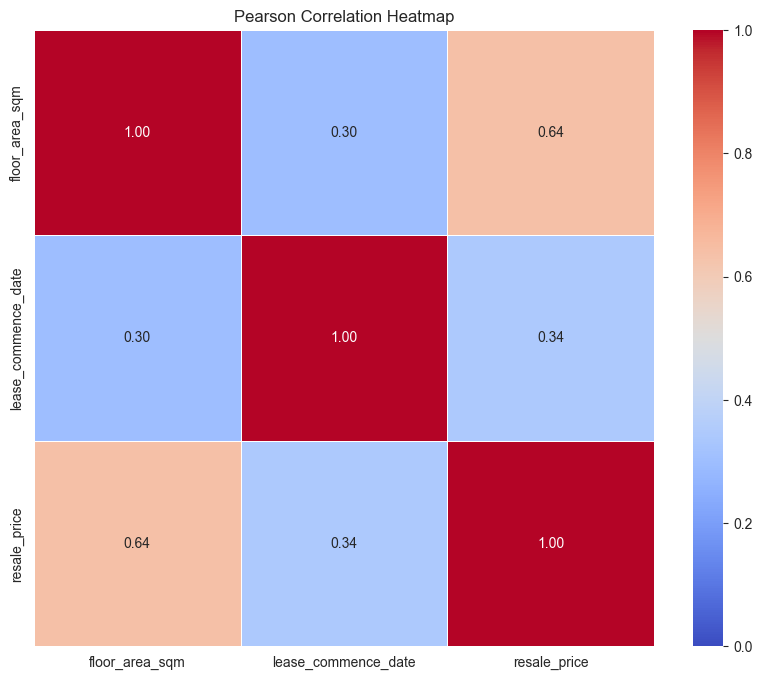

In [29]:
# Absolute negative years values
df['lease_commence_date'] = df['lease_commence_date'].abs()  
  
# Select continuous variables  
continuous_vars_all = df[['floor_area_sqm', 'lease_commence_date', 'resale_price']]

# Calculate the Pearson correlation matrix for the entire dataset
corr_matrix_pear = continuous_vars_all.corr(method='pearson')

# Plot the heatmap of the correlation matrix for the entire dataset
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_pear, annot=True, cmap='coolwarm', vmin=0, center=0.5, vmax=1, linewidths=0.5, fmt=".2f")
plt.title('Pearson Correlation Heatmap')
plt.show()

## Implementing Spearman Rank Correlation Coefficient

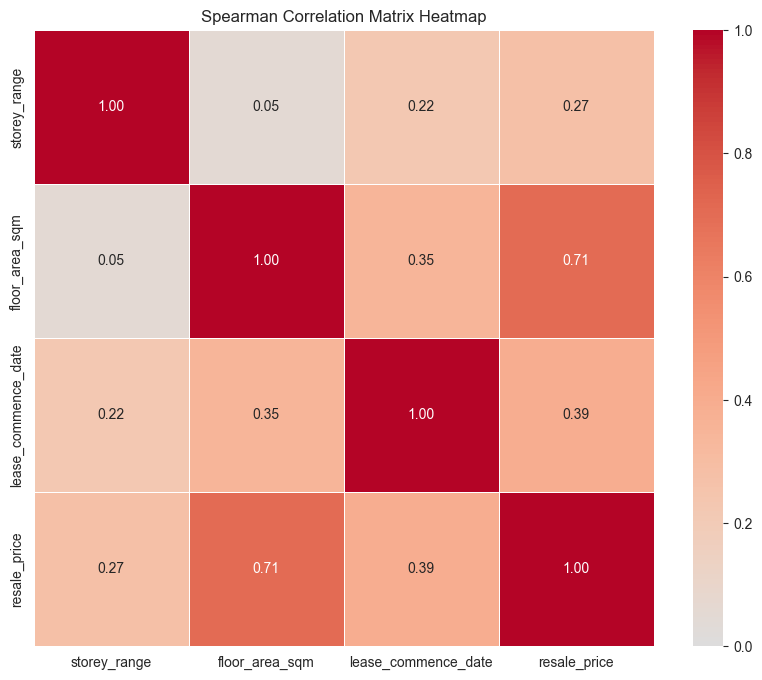

In [30]:
# Function to convert storey_range to ordinal scale by taking the average of the range
def convert_storey_range(storey_range: str) -> float:
    """
    Converts a storey range string into its average numerical value.
    
    The function takes a storey range in the format 'XX TO YY', splits it into two parts,
    converts these parts to integers, and returns the average of these integers.
    
    Args:
        storey_range (str): A string representing a range of storeys, in the format 'XX TO YY'.
        
    Returns:
        float: The average value of the two storeys in the range.
        
    Example:
        convert_storey_range('07 TO 09') -> 8.0
    """
    range_values = storey_range.split(' TO ')
    return (int(range_values[0]) + int(range_values[1])) / 2

# Use the .apply() method to convert the 'storey_range' column with the function
df['storey_range'] = df['storey_range'].apply(convert_storey_range)

# Select relevant columns for correlation analysis
spearman_vars = df[['storey_range', 'floor_area_sqm', 'lease_commence_date', 'resale_price']]

# Compute the Spearman correlation matrix
spearman_corr = spearman_vars.corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0, vmin=0, vmax=1, linewidths=0.5, fmt=".2f")
plt.title('Spearman Correlation Matrix Heatmap')
plt.show()